In [13]:
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm  import LinearSVC
from sklearn.model_selection import train_test_split , cross_validate 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder , MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , recall_score , ConfusionMatrixDisplay , precision_score , f1_score, RocCurveDisplay



In [14]:
dataframe = pd.read_csv("../processed_data/procesed_customer_churn.csv")
df = dataframe.copy()

In [15]:
df = df.drop(columns=['Unnamed: 0' , 'CustomerID'])

## Model Training

In [16]:
X = df.drop(columns=["Churn"])
Y = df["Churn"]


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 


In [18]:
preprocessor = ColumnTransformer(
    transformers= [
        ("num_scalar" , MinMaxScaler() , ["Age" ,"Tenure" ,"Usage Frequency","Support Calls", "Payment Delay","Total Spend","Last Interaction"]),
        ("cat_encoder" , OneHotEncoder(drop="first", sparse_output=False) , ["Gender" ,"Subscription Type" , "Contract Length"])

    ],
    remainder="passthrough"
)


In [19]:
svm_pipe = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model", LinearSVC(random_state=42))

]
)
## Starting withh default parameters can hyperparameter tune when needed 


### Cross Validation:

In [20]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cr_val_score = cross_validate(svm_pipe , X_train , y_train , cv=5 , scoring=scoring)
print("Mean Accuracy:", cr_val_score["test_accuracy"].mean())
print("Mean Precision:", cr_val_score["test_precision"].mean())
print("Mean Recall:", cr_val_score["test_recall"].mean())



Mean Accuracy: 0.8952064990855344
Mean Precision: 0.9275628400941622
Mean Recall: 0.8841691888241326


### Training Time:

In [21]:
start_train = time.perf_counter()
svm_pipe.fit(X_train, y_train)
end_train = time.perf_counter()


training_time = end_train -  start_train
print(f"Training time: {training_time:.6f} seconds")

Training time: 1.900223 seconds


### Prediction Time:

In [22]:
start_predict = time.perf_counter()
y_pred = svm_pipe.predict(X_test)
end_predict = time.perf_counter()


prediction_time  =  end_predict - start_predict
print(f"Prediction time: {prediction_time:.6f} seconds")



Prediction time: 0.122207 seconds


### Evaluation Matrix

Testing Scores::
Classification_report:               precision    recall  f1-score   support

           0       0.86      0.91      0.88     38063
           1       0.93      0.89      0.91     50104

    accuracy                           0.90     88167
   macro avg       0.89      0.90      0.90     88167
weighted avg       0.90      0.90      0.90     88167



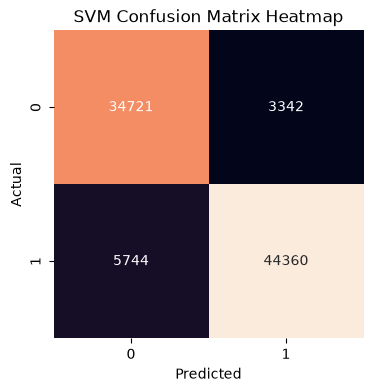

In [23]:

print("Testing Scores::")
report_test = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
print(f"Classification_report: {classification_report(y_test , y_pred)}")
cm = confusion_matrix(y_test , y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm , annot=True ,fmt="d" , cbar=False)
plt.title("Evaluationn on Test Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix Heatmap")

# Save the figure
plt.savefig('../benchmark_outputs/Svm_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [24]:
import joblib

# 1. Save your trained pipeline to a file
joblib.dump(svm_pipe, '../models/SVM_model_pipeline.joblib')

['../models/SVM_model_pipeline.joblib']